In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
aqi=pd.read_csv('city_day.csv')
aqi

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [3]:
aqi.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
aqi.shape

(29531, 16)

In [5]:
aqi.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


In [6]:
aqi.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [7]:
aqi.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='str')

In [8]:
aqi.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
aqi.drop('Xylene',axis=1,inplace=True)

In [10]:
aqi.dropna(subset=['AQI','AQI_Bucket'],inplace=True)

In [11]:
col_fill=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in col_fill:
    fill_mean=aqi[col].mean()
    aqi[col]=aqi[col].fillna(fill_mean)
    

In [12]:
aqi.shape

(24850, 15)

In [13]:
aqi.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [14]:
aqi['Date']==pd.to_datetime(aqi['Date'])

28       False
29       False
30       False
31       False
32       False
         ...  
29526    False
29527    False
29528    False
29529    False
29530    False
Name: Date, Length: 24850, dtype: bool

In [15]:
aqi["Date"].dtype

<StringDtype(na_value=nan)>

In [16]:
aqi["Date"].min()

'2015-01-01'

In [17]:
aqi["Date"].max()

'2020-07-01'

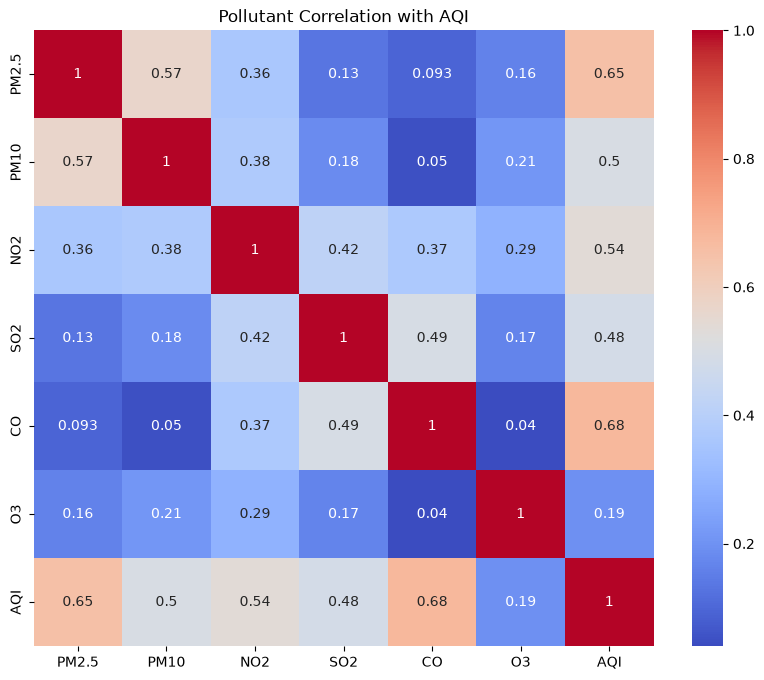

In [18]:
#heatmap
plt.figure(figsize=(10, 8))
cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI']
sns.heatmap(aqi[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Pollutant Correlation with AQI')
plt.show()

## Key Finding 1: PM10 is the Strongest AQI Predictor

The correlation heatmap reveals that **PM10 has the highest 
correlation with AQI (r = 0.80)**, followed by CO (0.68) and 
PM2.5 (0.66). This suggests that particulate matter (PM10) 
is the dominant driver of air quality index in Indian cities 
during 2015–2020.

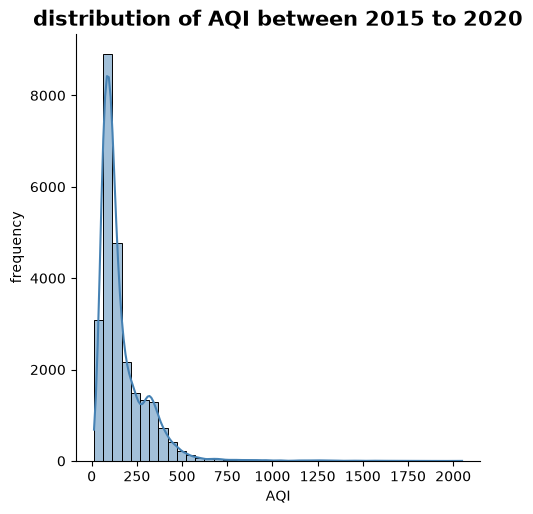

In [19]:
#for distribution use hisplot
sns.displot(data=aqi,x='AQI',kind="hist",bins=40,color='steelblue',kde=True)
plt.ylabel('frequency')
plt.title('distribution of AQI between 2015 to 2020',fontsize=15,fontweight='bold')
plt.show()

## Key Finding 2: AQI is Right-Skewed with Extreme Pollution Events

The histogram reveals a **right-skewed distribution** where most 
AQI readings cluster between 0–250 (Good to Moderate). However, 
a long tail extends beyond 1000, indicating frequent severe 
pollution spikes across Indian cities from 2015–2020. This 
suggests air quality is generally manageable but periodically 
dangerous.

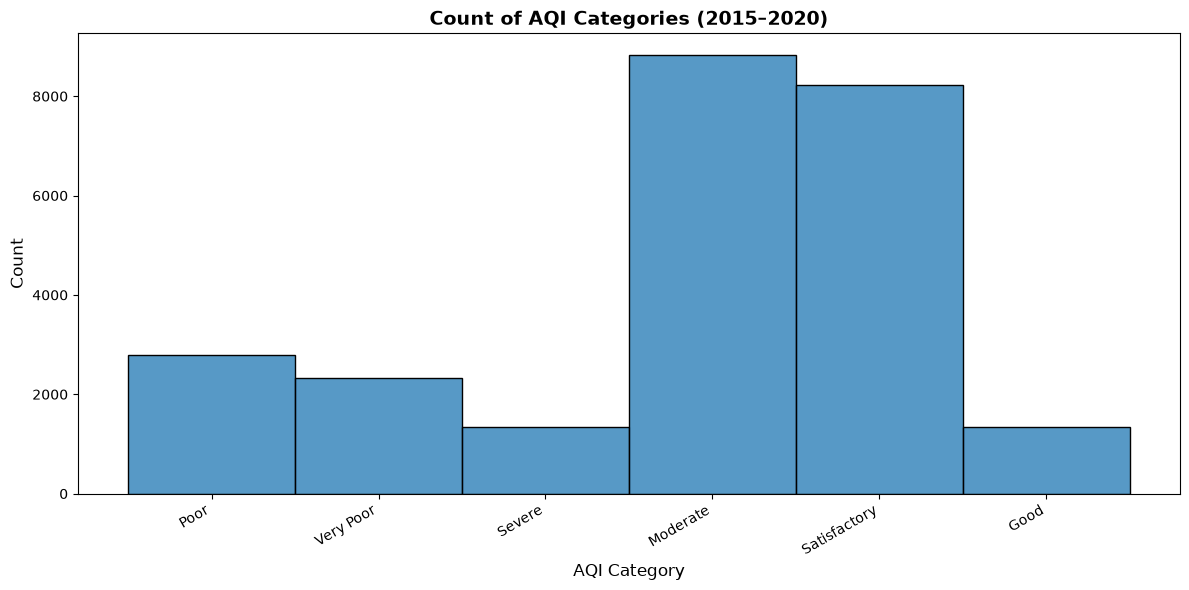

In [20]:
#aqi categories count
plt.figure(figsize=(12, 6))
sns.histplot(data=aqi,x="AQI_Bucket",bins=60)
plt.title('Count of AQI Categories (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('AQI Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=30,ha='right')
plt.tight_layout()


## Key Finding 3: Majority of Days Are Moderate to Satisfactory

The countplot reveals that Moderate (35%) and Satisfactory (33%)
categories dominate, accounting for over two-thirds of all readings. 
However, 25% of days fall into Poor, Very Poor, or Severe categories, 
indicating frequent unhealthy air quality periods. Only 5% of days 
achieve "Good" air quality, highlighting the chronic nature of air 
pollution in Indian cities.

In [22]:
aqi

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,83.13,118.454435,6.93,28.71,33.72,23.848366,6.93,49.52,59.76,0.020000,0.000000,209.0,Poor
29,Ahmedabad,2015-01-30,79.84,118.454435,13.85,28.68,41.08,23.848366,13.85,48.49,97.07,0.040000,0.000000,328.0,Very Poor
30,Ahmedabad,2015-01-31,94.52,118.454435,24.39,32.66,52.61,23.848366,24.39,67.39,111.33,0.240000,0.010000,514.0,Severe
31,Ahmedabad,2015-02-01,135.99,118.454435,43.48,42.08,84.57,23.848366,43.48,75.23,102.70,0.400000,0.040000,782.0,Severe
32,Ahmedabad,2015-02-02,178.33,118.454435,54.56,35.31,72.80,23.848366,54.56,55.04,107.38,0.460000,0.060000,914.0,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.940000,7.68,25.06,19.54,12.470000,0.47,8.55,23.30,2.240000,12.070000,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.090000,3.42,26.06,16.53,11.990000,0.52,12.72,30.14,0.740000,2.210000,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.730000,3.45,29.53,18.33,10.710000,0.48,8.42,30.96,0.010000,0.010000,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.970000,4.05,29.26,18.80,10.030000,0.52,9.84,28.30,0.000000,0.000000,54.0,Satisfactory


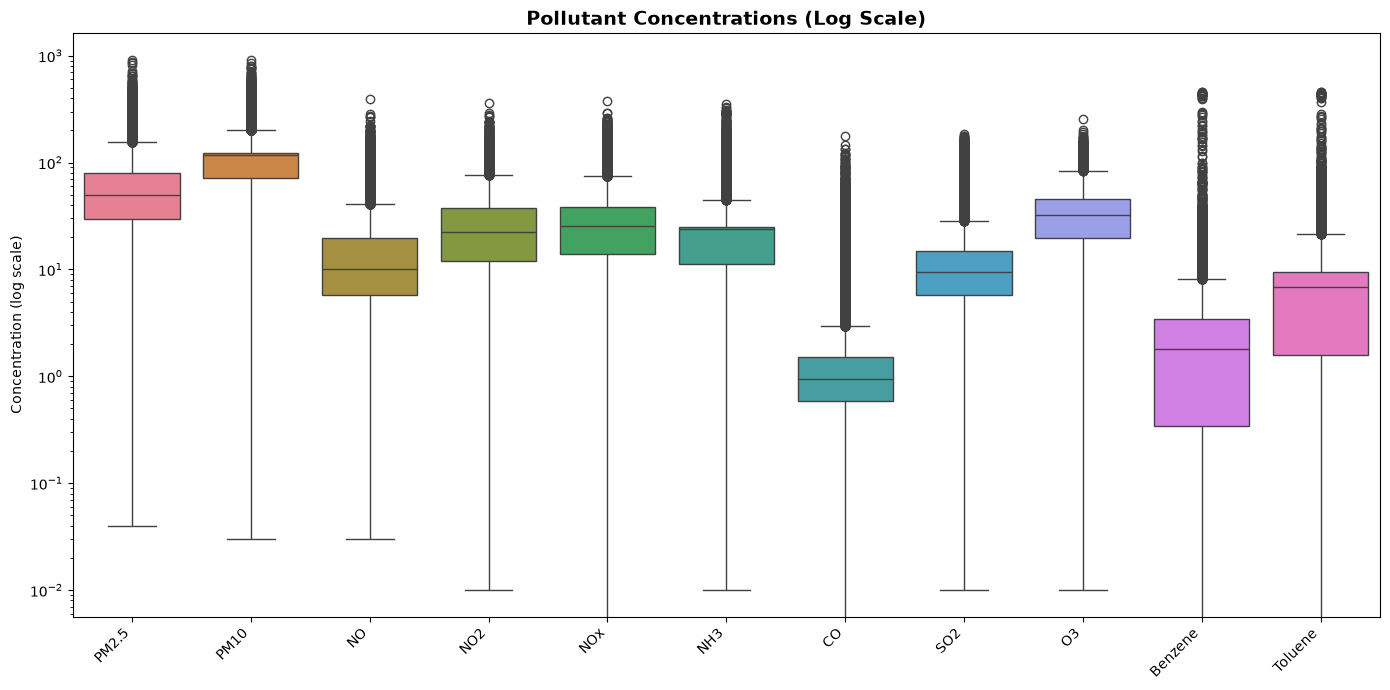

In [23]:
plt.figure(figsize=(14, 7))

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

sns.boxplot(data=aqi[pollutant_cols])
plt.yscale('log')  # Log scale because values differ wildly
plt.title('Pollutant Concentrations (Log Scale)', fontsize=14, fontweight='bold')
plt.ylabel('Concentration (log scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Key Finding 4: PM10 and PM2.5 Dominate with Extreme Outliers

The boxplot (log scale) reveals that PM10 has the highest median 
concentration, followed by PM2.5. Both show extensive outlier points 
beyond the upper whiskers, indicating frequent severe pollution events. 
CO exhibits the most dramatic variation — typically near zero but 
spiking to extreme values, suggesting episodic sources like vehicle 
exhaust or industrial accidents.

Text(0.5, 1.0, 'PM2.5 vs AQI by Category')

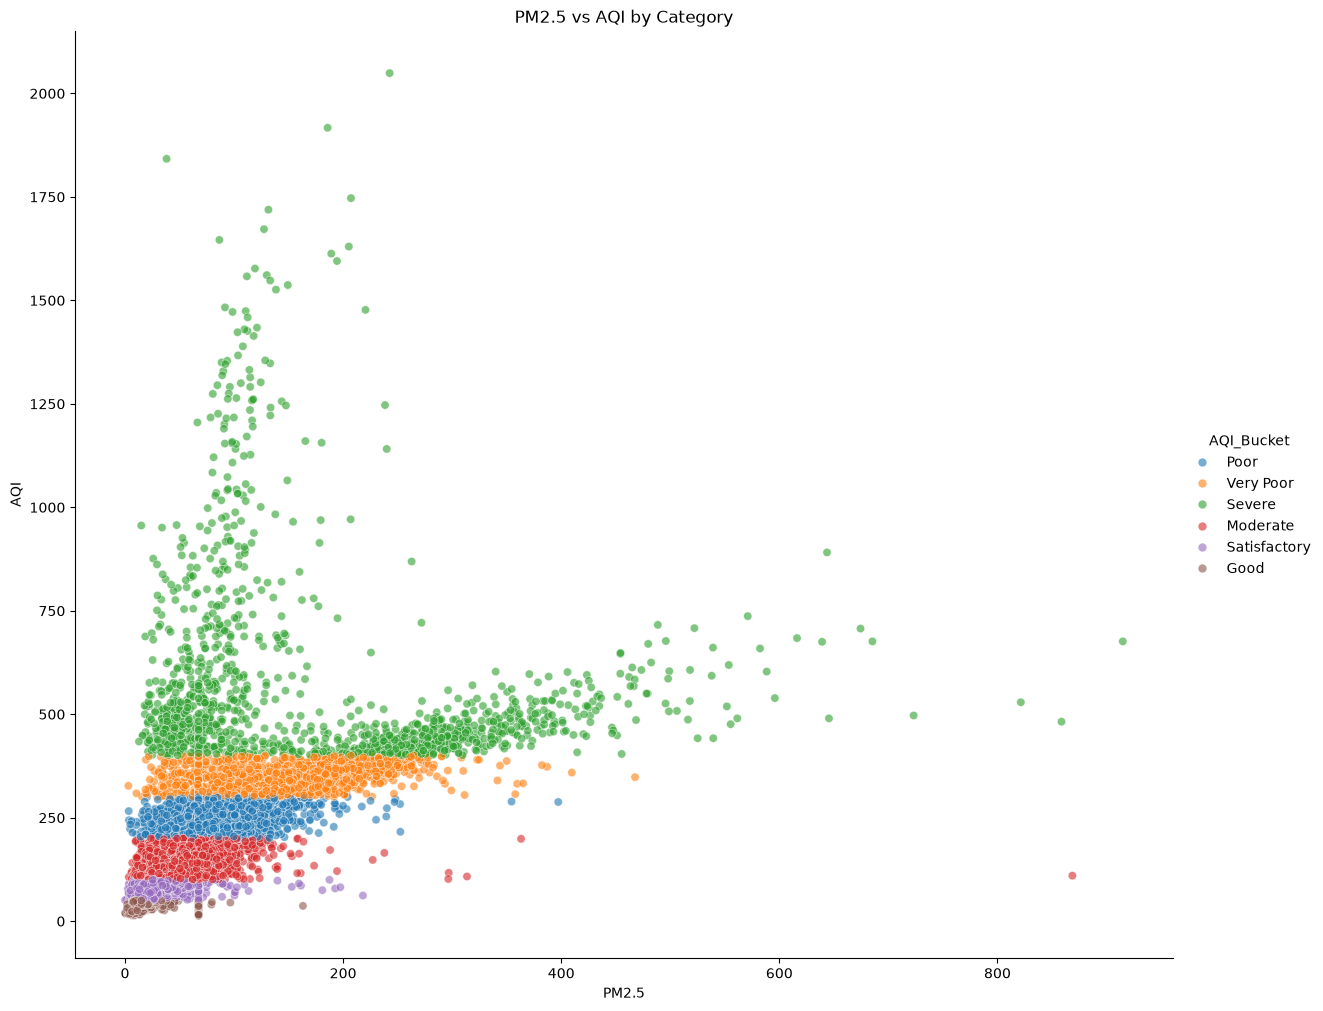

In [24]:
#scatterplot
sns.relplot(data=aqi,x='PM2.5',y='AQI',hue='AQI_Bucket',kind='scatter',alpha=0.6,height=10,aspect=1.2)
plt.title('PM2.5 vs AQI by Category')

## Key Finding 5: PM2.5 Shows Strong but Non-Linear Relationship with AQI

The scatter plot reveals a positive correlation between PM2.5 and AQI, 
with "Severe" categories (green) clustering at higher values. However, 
significant vertical spread exists at low PM2.5 concentrations, indicating 
that other pollutants (CO, NO2, SO2) substantially contribute to AQI
even when particulate matter is moderate. This suggests a multi-pollutant 
model will outperform single-feature prediction.

In [25]:
#lineplot
aqi



,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,83.13,118.454435,6.93,28.71,33.72,23.848366,6.93,49.52,59.76,0.020000,0.000000,209.0,Poor
29,Ahmedabad,2015-01-30,79.84,118.454435,13.85,28.68,41.08,23.848366,13.85,48.49,97.07,0.040000,0.000000,328.0,Very Poor
30,Ahmedabad,2015-01-31,94.52,118.454435,24.39,32.66,52.61,23.848366,24.39,67.39,111.33,0.240000,0.010000,514.0,Severe
31,Ahmedabad,2015-02-01,135.99,118.454435,43.48,42.08,84.57,23.848366,43.48,75.23,102.70,0.400000,0.040000,782.0,Severe
32,Ahmedabad,2015-02-02,178.33,118.454435,54.56,35.31,72.80,23.848366,54.56,55.04,107.38,0.460000,0.060000,914.0,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.940000,7.68,25.06,19.54,12.470000,0.47,8.55,23.30,2.240000,12.070000,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.090000,3.42,26.06,16.53,11.990000,0.52,12.72,30.14,0.740000,2.210000,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.730000,3.45,29.53,18.33,10.710000,0.48,8.42,30.96,0.010000,0.010000,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.970000,4.05,29.26,18.80,10.030000,0.52,9.84,28.30,0.000000,0.000000,54.0,Satisfactory


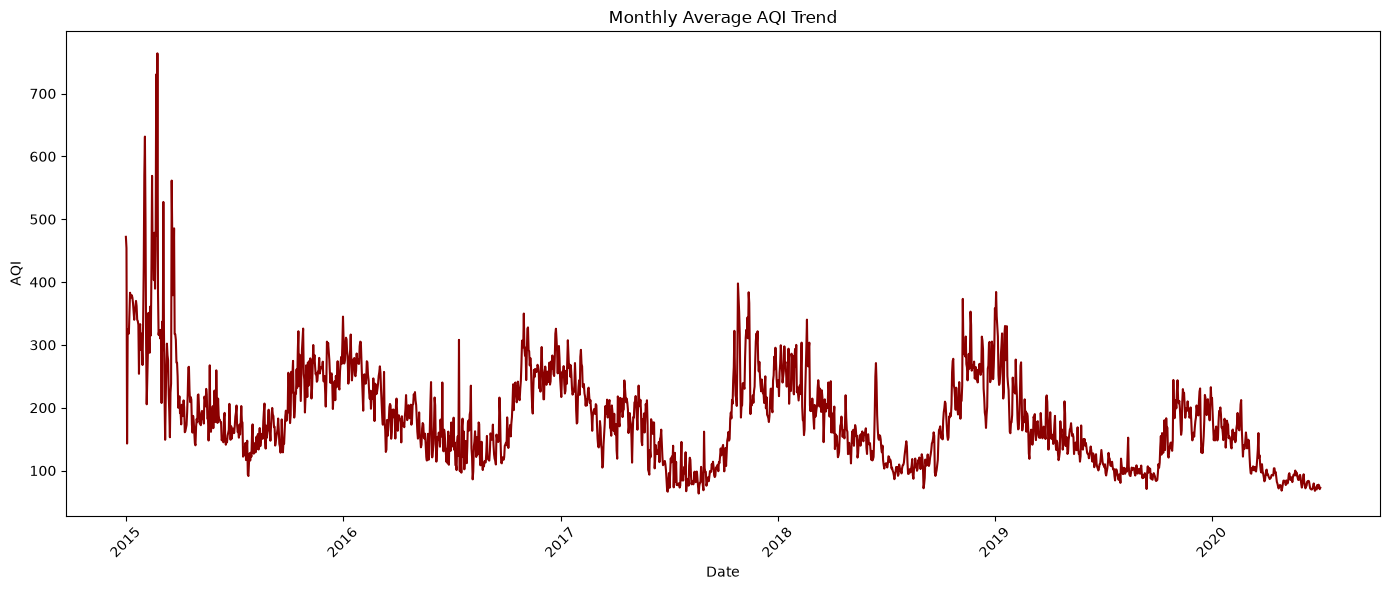

In [34]:
# Create Year-Month column
aqi['Date'] =pd.to_datetime (aqi['Date'])

# Group by it
monthly_aqi = aqi.groupby('Date')['AQI'].mean().reset_index()

# Plot (x-axis will be string labels)
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_aqi, x='Date', y='AQI', color='darkred')
plt.xticks(rotation=45)
plt.title('Monthly Average AQI Trend')
plt.tight_layout()
plt.show()

## Key Finding 6: Strong Seasonal Pattern with Long-Term Improvement

The time-series plot reveals **consistent winter peaks and summer 
troughs in AQI, driven by meteorological factors (temperature 
inversion, reduced wind speed) and increased heating emissions. 
2015 recorded the most extreme pollution events(AQI > 700), 
while 2020 shows the lowest levels, likely attributable to 
COVID-19 lockdowns reducing industrial and transportation emissions. 
This seasonal pattern is critical for forecasting modelsto 
incorporate month-of-year as a key feature.

<h1>CONCLUSION</h1>

| Finding                                                 | Implication                                                     |
| ------------------------------------------------------- | --------------------------------------------------------------- |
| **PM10 is the strongest AQI predictor** (r = 0.80)      | Prioritize PM10 monitoring in forecasting models                |
| **PM2.5 and CO are secondary drivers** (r = 0.66, 0.68) | Multi-pollutant models outperform single-feature approaches     |
| **AQI is right-skewed with extreme spikes**             | Most days are moderate, but severe events require alert systems |
| **68% of days are Moderate or Satisfactory**            | 25% still fall into Poor or worse — significant health risk     |
| **Strong winter peaks and summer troughs**              | Seasonal forecasting models must incorporate month-of-year      |
| **2020 shows lowest AQI levels**                        | COVID-19 lockdown demonstrates emission reduction potential     |


| Aspect         | Status                                                                           |
| -------------- | -------------------------------------------------------------------------------- |
| Missing values | Handled via mean imputation for pollutants; 15.9% AQI rows dropped               |
| Outliers       | Significant in all pollutants — retained as they represent real pollution events |
| Time coverage  | 5.5 years (Jan 2015 – Jul 2020) — sufficient for seasonal pattern detection      |


Limitations

1Single-city aggregation masks local variations — city-specific models may improve accuracy

2Mean imputation for missing values may underestimate extreme pollution events

3 Xylene dropped (61% missing) — potential loss of volatile organic compound signal